In [ ]:
# ============================================================
# Development settings
# ============================================================
%load_ext autoreload
%autoreload 2

# ============================================================
# Standard library
# ============================================================
import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# ============================================================
# Scientific / geospatial libraries
# ============================================================
import numpy as np
import pandas as pd
import geopandas as gpd
import h3

# ============================================================
# Project modules
# ============================================================
from src.hazard_framework import (
    hazard_scoring,
    assign_aggregation_framework,
    calculate_burden,
)

from src.plotting_function import *

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"

print("Project root:", PROJECT_ROOT)
print("Data:", DATA_DIR)
print("Figures:", FIGURE_DIR)

Project root: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification
Data: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data
Figures: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\figures


In [ ]:
gdf = gpd.read_parquet(DATA_DIR / '3hazard_final_update.parquet')
gdf.head()

In [ ]:
gdf = hazard_scoring(gdf)
gdf.head()

In [ ]:
gdf = assign_aggregation_framework(gdf)

In [ ]:
burden = calculate_burden(gdf)

In [ ]:
import matplotlib.colors as mcolors
fig, ax = initialize_map(figsize=(24,12))

key = 'MHB'

vmin = burden[key].quantile(0.01)
vmax = burden[key].quantile(0.99)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

burden.plot(
    column=key,
    cmap=plt.cm.magma_r,
    ax=ax,
    legend=True,
    edgecolor="black",
    alpha=0.7,
    linewidth=0.5,
        legend_kwds={
        # "label": "Conditional flood amplification ratio",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

cbar_ax = fig.axes[-1]
cbar_ax.set_xlabel(
    r"Multi-Hazard Burden ($MH_B$): local hazard concentration (LHC) × log(number of transects in cell)",
    fontsize=18
)

# for x, y, label in zip(
#     gdf_amp.geometry.representative_point().x,
#     gdf_amp.geometry.representative_point().y,
#     gdf_amp["Acronym"]
# ):
#     ax.text(x, y, label, ha="center", va="center")

plt.show()

In [3]:
ipccc_shp =r'f:\TUD_CEG_Repository\MSc_Thesis\Data\IPCC region\IPCC-WGI-reference-regions-v4.shp'
gdf = gpd.read_parquet(DATA_DIR / '3hazard_final_update.parquet')
gdf = hazard_scoring(gdf)
poly_gdf = assign_aggregation_framework(gdf,framework='polygon',polygon_file=ipccc_shp)
poly_gdf.head()

,transect_id,bearing,utm_epsg,sds:change_rate,buildings:dist_to_shoreline,class:is_built_environment,subsidence,dist_m,flood_mean,flood_max,...,S_E,S_S,S_F,S,category,Continent,Type,Name,Acronym,geometry
0,cl59611s01tr01839956,95.227142,32654,-0.276956,NaN,False,1.0,0.020362,NaN,NaN,...,1.0,1.0,NaN,2.0,low (0–2),ASIA,Land,E.Asia,EAS,"LINESTRING (141.97725 39.76326, 142.00048 39.7..."
1,cl59611s01tr01838556,336.772888,32654,0.329647,NaN,True,1.0,0.025815,NaN,NaN,...,0.0,1.0,NaN,1.0,low (0–2),ASIA,Land,E.Asia,EAS,"LINESTRING (142.00021 39.74381, 141.99124 39.7..."
2,cl59611s01tr01838656,15.629314,32654,-0.417924,75.495979,False,1.0,0.024717,NaN,NaN,...,1.0,1.0,NaN,2.0,low (0–2),ASIA,Land,E.Asia,EAS,"LINESTRING (141.99136 39.74346, 141.9979 39.76..."
3,cl59611s01tr01838756,35.037529,32654,-0.043039,NaN,False,1.0,0.023774,NaN,NaN,...,1.0,1.0,NaN,2.0,low (0–2),ASIA,Land,E.Asia,EAS,"LINESTRING (141.98683 39.74525, 142.00044 39.7..."
4,cl59611s01tr01838856,46.176598,32654,0.032917,NaN,False,1.0,0.023012,NaN,NaN,...,0.0,1.0,NaN,1.0,low (0–2),ASIA,Land,E.Asia,EAS,"LINESTRING (141.98428 39.74702, 142.0013 39.75..."


In [6]:
poly_burden = calculate_burden(poly_gdf,framework='polygon',polygon_file=ipccc_shp)

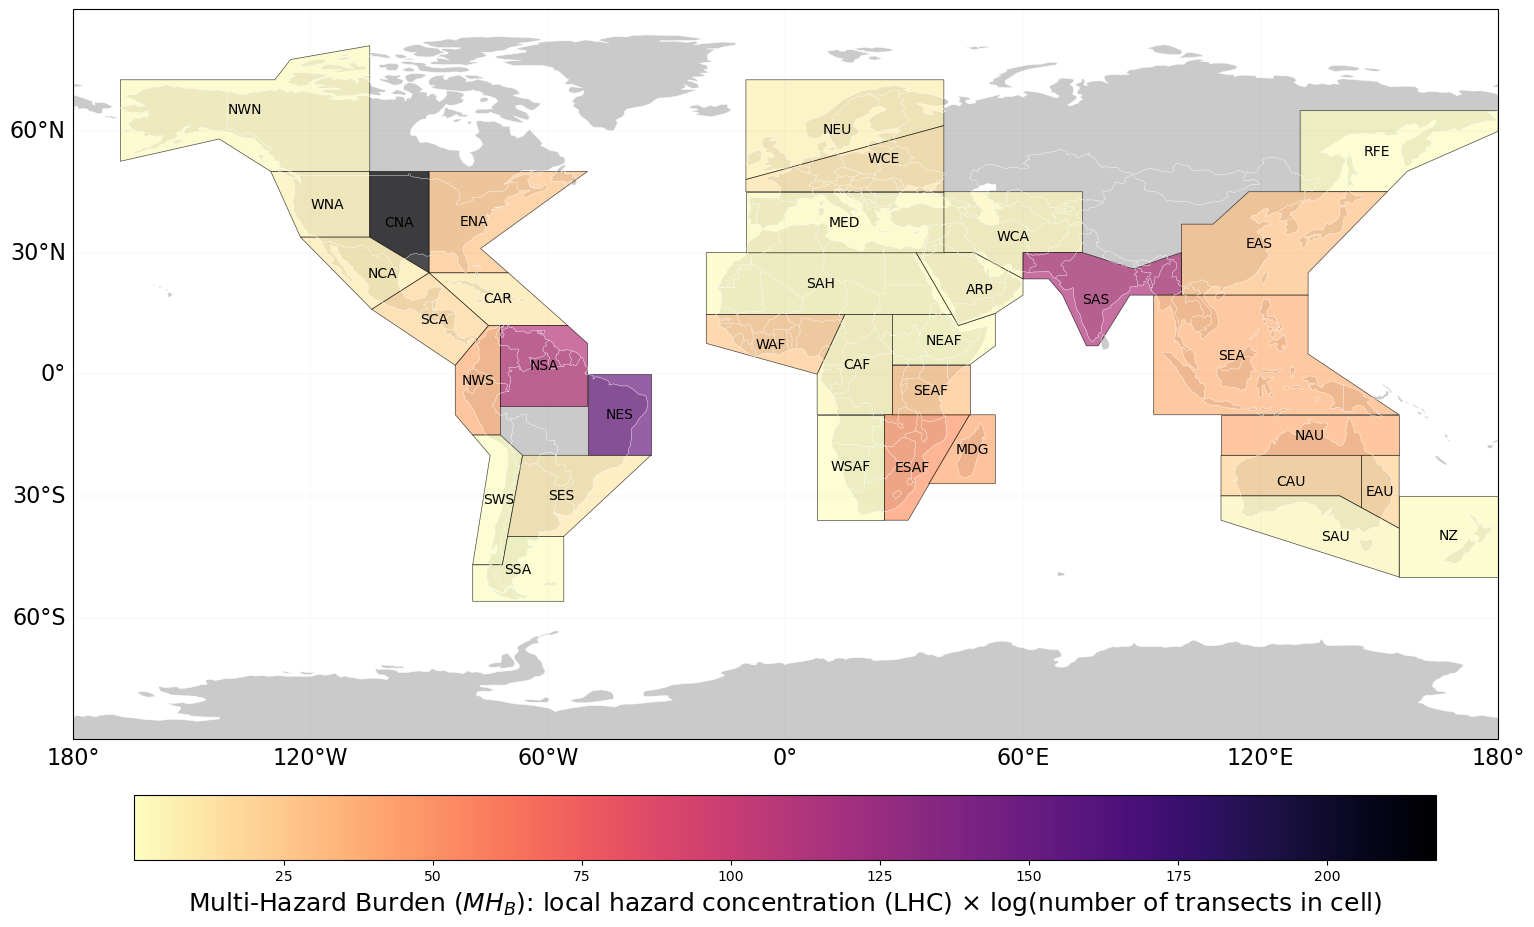

In [10]:
import matplotlib.colors as mcolors
fig, ax = initialize_map(figsize=(24,12))

key = 'MHB'

vmin = poly_burden[key].quantile(0.01)
vmax = poly_burden[key].quantile(0.99)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

poly_burden.plot(
    column=key,
    cmap=plt.cm.magma_r,
    ax=ax,
    legend=True,
    edgecolor="black",
    alpha=0.7,
    linewidth=0.5,
        legend_kwds={
        # "label": "Conditional flood amplification ratio",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

cbar_ax = fig.axes[-1]
cbar_ax.set_xlabel(
    r"Multi-Hazard Burden ($MH_B$): local hazard concentration (LHC) × log(number of transects in cell)",
    fontsize=18
)

for x, y, label in zip(
    poly_burden.geometry.representative_point().x,
    poly_burden.geometry.representative_point().y,
    poly_burden["Acronym"]
):
    ax.text(x, y, label, ha="center", va="center")

plt.show()